In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# =========================
# FIX NUMERIC COLUMNS IN CLEANED DATA
# =========================
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/cricket_dataset_cleaned.csv", low_memory=False)

# List of numeric columns
numeric_cols = [
    'over', 'ball', 'ball_no', 'bat_pos', 'runs_batter', 'balls_faced',
    'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
    'balls_per_over', 'overs', 'team_runs', 'team_balls', 'team_wicket',
    'batter_runs', 'batter_balls', 'bowler_wicket', 'match_number', 'runs_target',
    'non_striker_pos'
]
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Convert invalid strings to NaN and fill with 0
for col in numeric_cols:
    # Convert any non-numeric strings to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

    # Fill NaNs in this column with 0
    df[col] = df[col].fillna(0)

    # Convert to float
    df[col] = df[col].astype(float)


# Check if any numeric column still has non-numeric values
print(df[numeric_cols].dtypes)
print("✅ Numeric columns fixed")


over                 float64
ball                 float64
ball_no              float64
bat_pos              float64
runs_batter          float64
balls_faced          float64
runs_extras          float64
runs_total           float64
runs_bowler          float64
runs_not_boundary    float64
balls_per_over       float64
overs                float64
team_runs            float64
team_balls           float64
team_wicket          float64
batter_runs          float64
batter_balls         float64
bowler_wicket        float64
match_number         float64
runs_target          float64
non_striker_pos      float64
dtype: object
✅ Numeric columns fixed


Data Shape: (278205, 58)

Columns:
 ['match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'batter_runs', 'batter_balls', 'bowler_wicket']

Missing Values After Fix:
 match_id                  0
date                      0
match_type                0
event_name                0
innings                   0
batting_tea

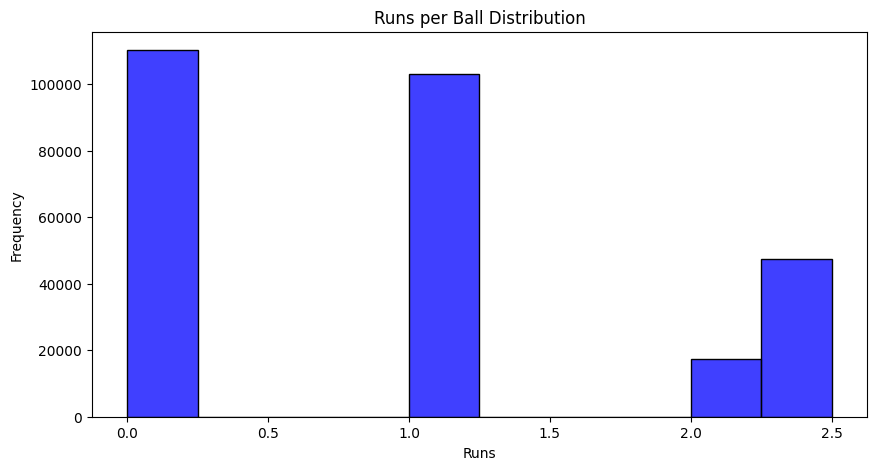

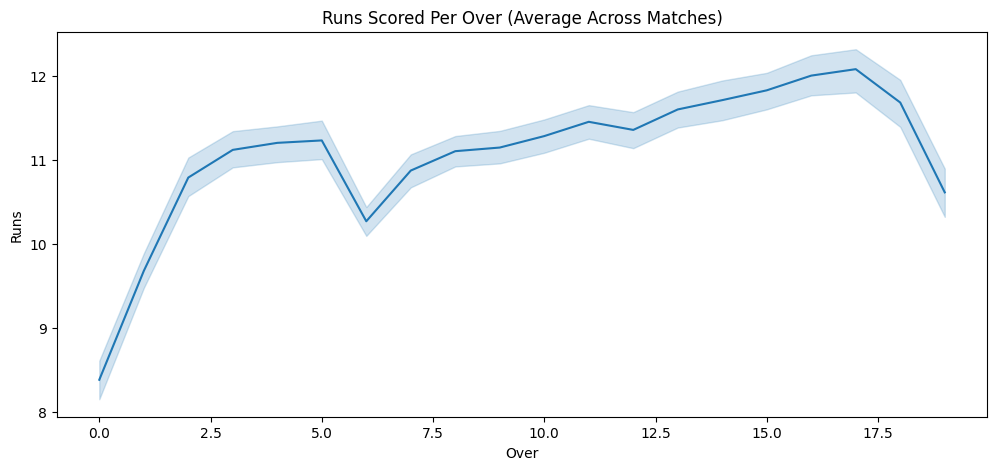

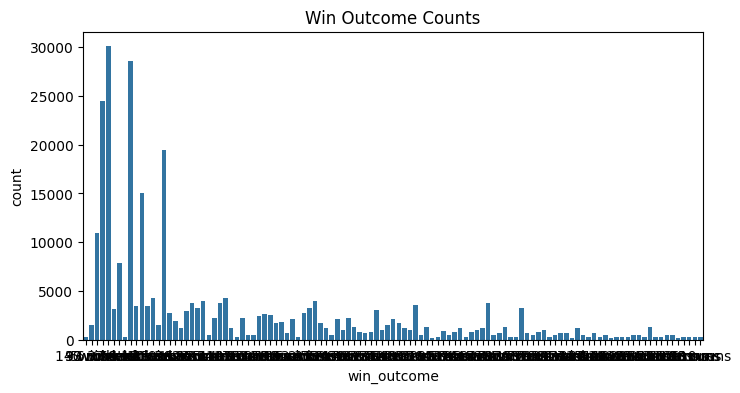

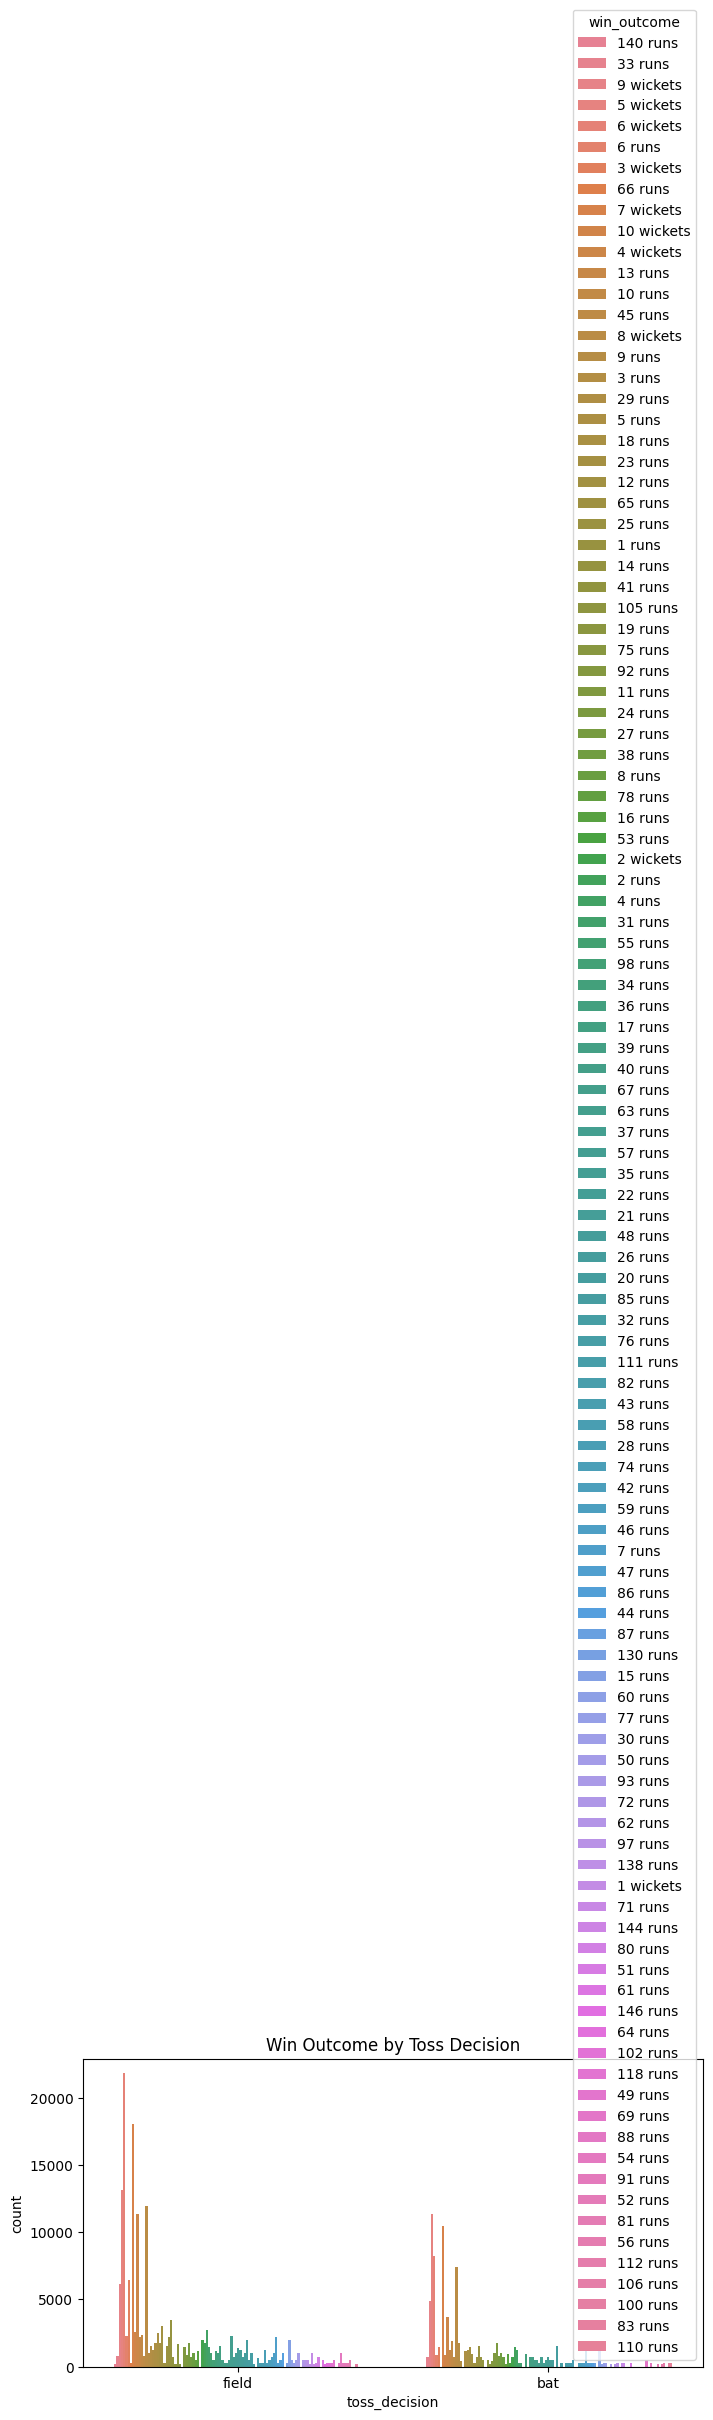

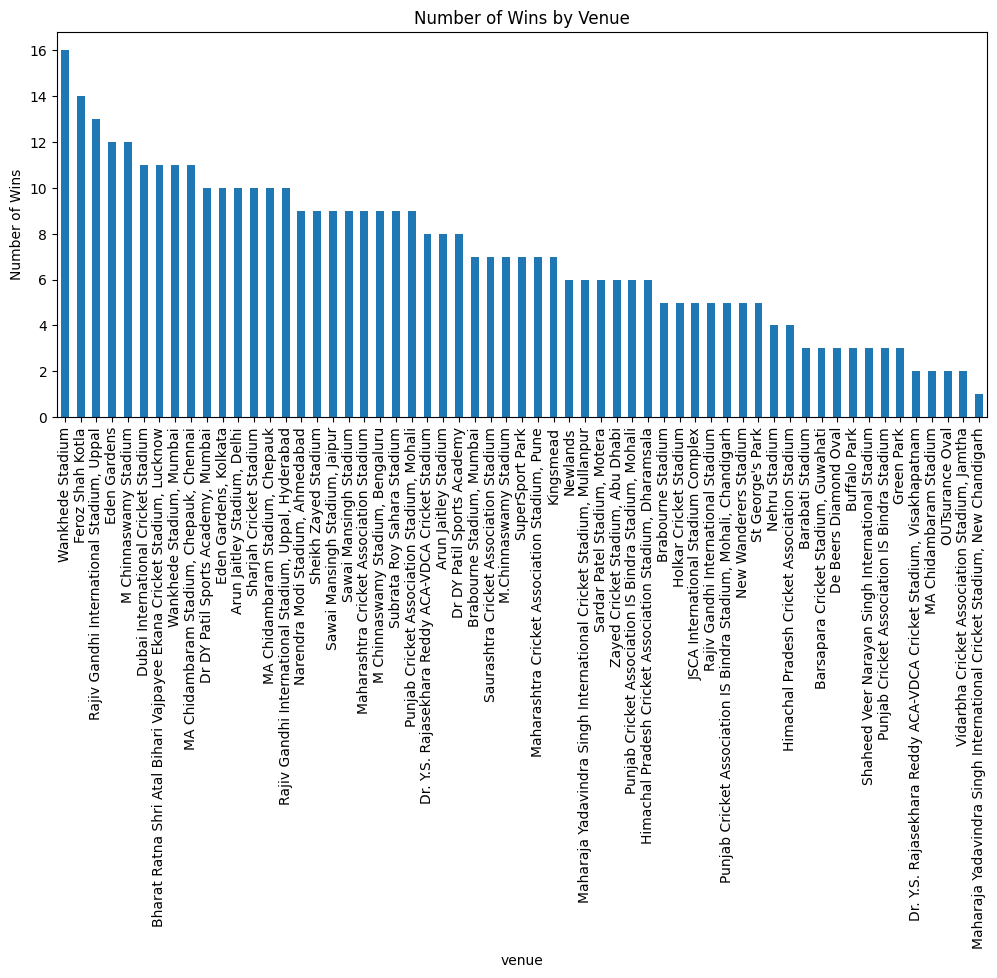

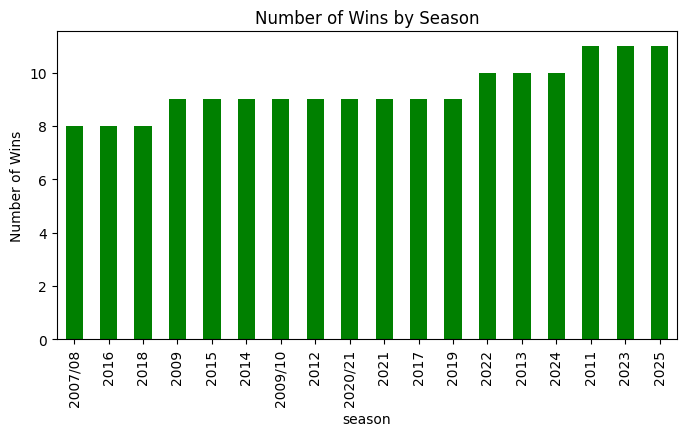

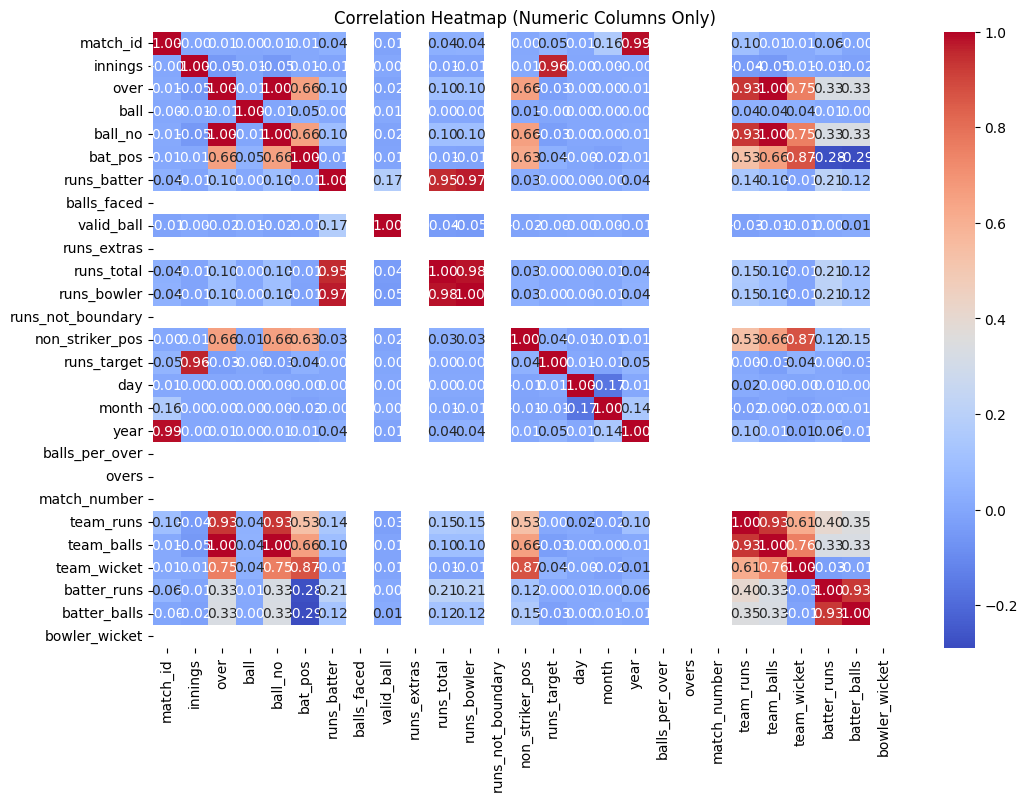

✅ Full EDA Completed Successfully


In [16]:
# =========================
# FULL EDA PIPELINE FOR CLEANED CRICKET DATA
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# STEP 1: LOAD CLEANED DATA
# =========================
df = pd.read_csv("/content/drive/MyDrive/cricket_dataset_cleaned.csv", low_memory=False)
print("Data Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

# =========================
# STEP 2: FIX NUMERIC COLUMNS
# =========================
numeric_cols = [
    'over', 'ball', 'ball_no', 'bat_pos', 'runs_batter', 'balls_faced',
    'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
    'balls_per_over', 'overs', 'team_runs', 'team_balls', 'team_wicket',
    'batter_runs', 'batter_balls', 'bowler_wicket', 'match_number', 'runs_target',
    'non_striker_pos'
]
numeric_cols = [col for col in numeric_cols if col in df.columns]

for col in numeric_cols:
    # Convert any non-numeric strings to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaNs with 0
    df[col] = df[col].fillna(0)
    # Convert to float
    df[col] = df[col].astype(float)

# =========================
# STEP 3: FIX DATE COLUMN
# =========================
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# =========================
# STEP 4: CHECK MISSING VALUES
# =========================
print("\nMissing Values After Fix:\n", df.isnull().sum())

# =========================
# STEP 5: EXPLORATORY DATA ANALYSIS
# =========================

# ----- 5a: Top Batting Teams -----
if 'batting_team' in df.columns:
    team_runs = df.groupby('batting_team')['runs_batter'].sum().sort_values(ascending=False)
    print("\nTop Batting Teams:\n", team_runs.head(10))

# ----- 5b: Top Bowlers -----
if 'bowler' in df.columns:
    top_bowlers = df.groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False)
    print("\nTop Bowlers:\n", top_bowlers.head(10))

# ----- 5c: Top Batters -----
if 'batter' in df.columns:
    top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False)
    print("\nTop Batters:\n", top_batters.head(10))

# ----- 5d: Runs per Ball Distribution -----
plt.figure(figsize=(10,5))
sns.histplot(df['runs_batter'], bins=10, kde=False, color='blue')
plt.title("Runs per Ball Distribution")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

# ----- 5e: Runs per Over -----
if 'over' in df.columns and 'match_id' in df.columns:
    over_runs = df.groupby(['match_id', 'over'])['runs_batter'].sum().reset_index()
    plt.figure(figsize=(12,5))
    sns.lineplot(data=over_runs, x='over', y='runs_batter')
    plt.title("Runs Scored Per Over (Average Across Matches)")
    plt.xlabel("Over")
    plt.ylabel("Runs")
    plt.show()

# ----- 5f: Win Outcome Analysis -----
if 'win_outcome' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x='win_outcome', data=df)
    plt.title("Win Outcome Counts")
    plt.show()

# Toss Decision vs Win Outcome
if 'toss_decision' in df.columns and 'win_outcome' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x='toss_decision', hue='win_outcome', data=df)
    plt.title("Win Outcome by Toss Decision")
    plt.show()

# ----- 5g: Venue Analysis -----
if 'venue' in df.columns and 'match_won_by' in df.columns:
    plt.figure(figsize=(12,5))
    venue_wins = df.groupby('venue')['match_won_by'].nunique().sort_values(ascending=False)
    venue_wins.plot(kind='bar')
    plt.title("Number of Wins by Venue")
    plt.ylabel("Number of Wins")
    plt.show()

# ----- 5h: Season Analysis -----
if 'season' in df.columns and 'match_won_by' in df.columns:
    plt.figure(figsize=(8,4))
    season_wins = df.groupby('season')['match_won_by'].nunique().sort_values()
    season_wins.plot(kind='bar', color='green')
    plt.title("Number of Wins by Season")
    plt.ylabel("Number of Wins")
    plt.show()

# ----- 5i: Correlation Heatmap (Numeric Columns Only) -----
numeric_df = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Columns Only)")
plt.show()

print("✅ Full EDA Completed Successfully")


In [17]:
# Save the fixed dataset
df.to_csv("/content/drive/MyDrive/cricket_dataset_cleaned_fixed.csv", index=False)
print("✅ Fixed dataset saved as 'cricket_dataset_cleaned_fixed.csv'")


✅ Fixed dataset saved as 'cricket_dataset_cleaned_fixed.csv'
